# 02 — Evaluate & Diagnostic Plots
Loads trained models and saved test-split artifacts, then produces all diagnostic plots.

**Run after:** `01_train.ipynb`

In [1]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

os.makedirs("pipeline_v2/artifacts", exist_ok=True)

# ── Load models ──
m = "pipeline_v2/models"
a = "pipeline_v2/artifacts"

global_scaler = joblib.load(f"{m}/scaler.pkl")
scaler_fruit  = joblib.load(f"{m}/scaler_fruit.pkl")
scaler_fresh  = joblib.load(f"{m}/scaler_fresh.pkl")
rfe_fruit     = joblib.load(f"{m}/rfe_fruit.pkl")
rfe_fresh     = joblib.load(f"{m}/rfe_fresh.pkl")
svm_fruit     = joblib.load(f"{m}/svm_fruit.pkl")
dasfs_dict    = joblib.load(f"{m}/dasfs.pkl")
knn_bundle    = joblib.load(f"{m}/knn_dict.pkl")
knn_dict      = knn_bundle["knn_dict"]
tau_dict      = knn_bundle["tau_dict"]
top300_idx    = np.load(f"{a}/top300_cmi.npy")

# ── Load test split artifacts ──
X_fruit_test  = np.load(f"{a}/X_fruit_test.npy")
X_fresh_test  = np.load(f"{a}/X_fresh_test.npy")
y_test        = np.load(f"{a}/y_test.npy")
ft_test       = np.load(f"{a}/ft_test.npy",  allow_pickle=True)
X_fruit_train = np.load(f"{a}/X_fruit_train.npy")

# Needed for CV result plots (loaded from train notebook globals if available)
# Fallback: skip accuracy-vs-features plot if not in memory
fruit_cv_results = globals().get("fruit_cv_results", None)
fresh_cv_results = globals().get("fresh_cv_results", None)

FRUITS = sorted(np.unique(ft_test).tolist())
print("Models loaded.")
print(f"Test samples: {len(y_test)}  |  Fruits: {FRUITS}")


Models loaded.
Test samples: 2759  |  Fruits: ['freshapple', 'freshbanana', 'freshcapsicum', 'freshcarrot', 'freshcucumber', 'freshpotato', 'rottenapple', 'rottenbanana', 'rottencapsicum', 'rottencarrot', 'rottencucumber', 'rottenpotato']


### Fruit classifier evaluation

In [2]:
pred_fruit = svm_fruit.predict(X_fruit_test)
acc_fruit  = accuracy_score(ft_test, pred_fruit)
print(f"Fruit accuracy: {acc_fruit:.4f}\n")
print(classification_report(ft_test, pred_fruit))


Fruit accuracy: 0.9804

                precision    recall  f1-score   support

    freshapple       1.00      1.00      1.00       390
   freshbanana       1.00      1.00      1.00       421
 freshcapsicum       0.99      1.00      1.00       187
   freshcarrot       0.99      1.00      1.00       119
 freshcucumber       0.94      0.97      0.95        87
   freshpotato       0.95      0.95      0.95       131
   rottenapple       0.99      0.98      0.99       507
  rottenbanana       1.00      1.00      1.00       519
rottencapsicum       0.95      0.90      0.92        41
  rottencarrot       0.99      0.94      0.96        99
rottencucumber       0.92      0.87      0.90        95
  rottenpotato       0.88      0.93      0.90       163

      accuracy                           0.98      2759
     macro avg       0.97      0.96      0.96      2759
  weighted avg       0.98      0.98      0.98      2759



### DASFS freshness evaluation

In [3]:
def dasfs_predict(x_vec, fruit, dasfs_dict):
    d     = dasfs_dict[fruit]
    proj  = float(x_vec @ d["axis"])
    p_f, p_r, spread = d["p_fresh"], d["p_rotten"], d["spread"]
    score = float(np.clip((p_r - proj) / (p_r - p_f + 1e-8), 0.0, 1.0))
    mid   = (p_f + p_r) / 2.0
    u     = float(np.exp(-((proj - mid) ** 2) / (2.0 * spread ** 2 + 1e-8)))
    conf  = float(np.clip(1.0 - u, 0.0, 1.0))
    return score, conf

scores_list = []
for i in range(len(X_fresh_test)):
    f = ft_test[i]
    if f not in dasfs_dict:
        continue
    s, c = dasfs_predict(X_fresh_test[i], f, dasfs_dict)
    scores_list.append((s, c, int(y_test[i])))

scores_arr  = np.array(scores_list)
pred_binary = (scores_arr[:,0] > 0.5).astype(int)
true_binary = (scores_arr[:,2] == 0).astype(int)
print("DASFS Test Accuracy:", accuracy_score(true_binary, pred_binary))
print(classification_report(true_binary, pred_binary, target_names=["Rotten", "Fresh"]))


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

### Plot 1: Accuracy vs feature count
*(Requires `fruit_cv_results` / `fresh_cv_results` from `01_train` — skipped if not available)*

In [4]:
if fruit_cv_results and fresh_cv_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, results, title, color in zip(
        axes,
        [fruit_cv_results, fresh_cv_results],
        ["Fruit Features (RFE → SVC)", "Freshness Features (CMI-RFE → SVC)"],
        ["#1f77b4", "#2ca02c"]
    ):
        ns   = [r[0] for r in results]
        accs = [r[1] for r in results]
        best_idx = int(np.argmax(accs))
        ax.plot(ns, accs, marker="o", color=color, linewidth=2, markersize=8)
        ax.scatter([ns[best_idx]], [accs[best_idx]], color="red", zorder=5,
                   s=120, label=f"Best: n={ns[best_idx]} ({accs[best_idx]:.4f})")
        ax.set_xlabel("Number of Features"); ax.set_ylabel("5-Fold CV Accuracy")
        ax.set_title(title, fontweight="bold"); ax.set_xticks(ns)
        ax.legend(); ax.grid(alpha=0.35)
    plt.tight_layout()
    plt.savefig(f"{a}/plot_accuracy_vs_features.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → plot_accuracy_vs_features.png")
else:
    print("CV results not in memory — re-run 01_train or run this notebook in the same session.")


CV results not in memory — re-run 01_train or run this notebook in the same session.


### Plot 2: PCA cluster visualisation *(diagnostic only — PCA not used in pipeline)*

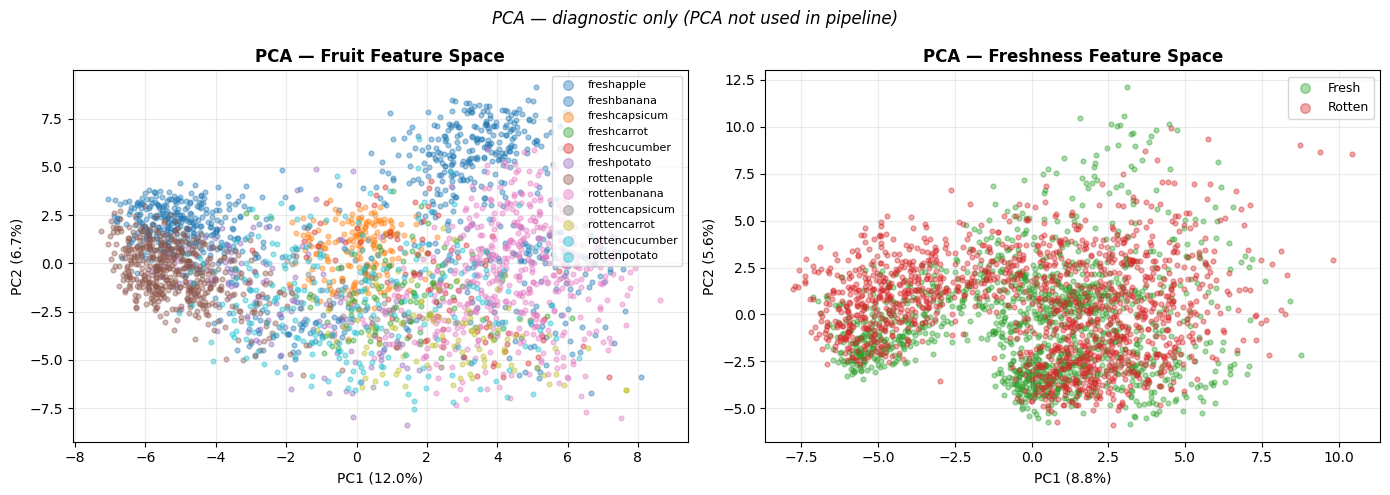

Saved → plot_pca.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pca2  = PCA(n_components=2, random_state=42)
Xf_pc = pca2.fit_transform(X_fruit_test)
fruit_labels = np.unique(ft_test)
cmap_f = plt.cm.get_cmap("tab10", len(fruit_labels))
for i, fl in enumerate(fruit_labels):
    mask = ft_test == fl
    axes[0].scatter(Xf_pc[mask, 0], Xf_pc[mask, 1],
                    alpha=0.4, s=12, color=cmap_f(i), label=fl)
axes[0].set_title("PCA — Fruit Feature Space", fontweight="bold")
axes[0].legend(markerscale=2, fontsize=8)
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].grid(alpha=0.25)

pca2b  = PCA(n_components=2, random_state=42)
Xr_pc  = pca2b.fit_transform(X_fresh_test)
for lbl, clr, nm in [(0, "#2ca02c", "Fresh"), (1, "#d62728", "Rotten")]:
    mask = y_test == lbl
    axes[1].scatter(Xr_pc[mask, 0], Xr_pc[mask, 1],
                    alpha=0.4, s=12, color=clr, label=nm)
axes[1].set_title("PCA — Freshness Feature Space", fontweight="bold")
axes[1].legend(markerscale=2, fontsize=9)
axes[1].set_xlabel(f"PC1 ({pca2b.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca2b.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].grid(alpha=0.25)

plt.suptitle("PCA — diagnostic only (PCA not used in pipeline)", style="italic")
plt.tight_layout()
plt.savefig(f"{a}/plot_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot_pca.png")


### Plot 3: KNN distance distribution per fruit

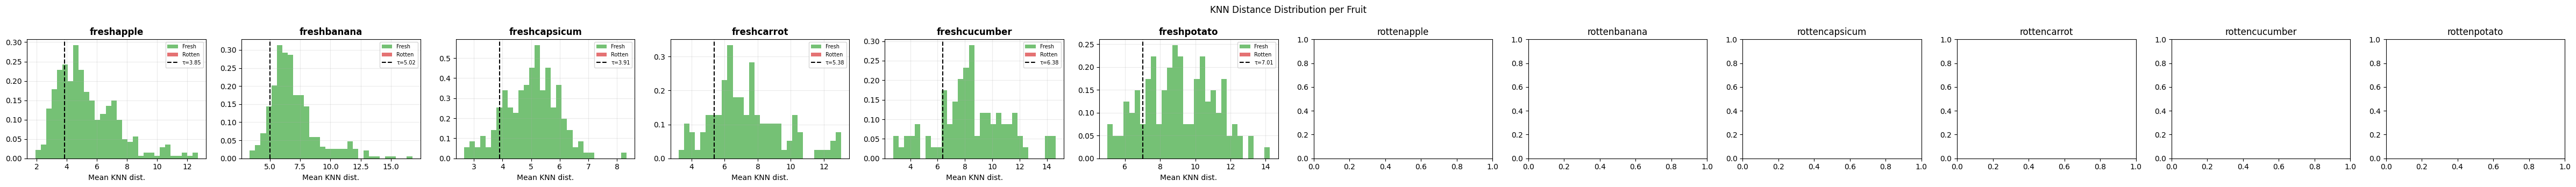

Saved → plot_knn_dist.png


In [10]:
fig, axes = plt.subplots(1, len(FRUITS), figsize=(4 * len(FRUITS), 3.5))
if len(FRUITS) == 1:
    axes = [axes]
for ax, fruit in zip(axes, FRUITS):
    if fruit not in knn_dict:
        ax.set_title(fruit); continue
    mask  = ft_test == fruit
    dists, _ = knn_dict[fruit].kneighbors(X_fresh_test[mask])
    kdist = dists.mean(axis=1)
    yfr   = y_test[mask]
    ax.hist(kdist[yfr == 0], bins=30, alpha=0.65, color="#2ca02c", label="Fresh", density=True)
    ax.hist(kdist[yfr == 1], bins=30, alpha=0.65, color="#d62728", label="Rotten", density=True)
    ax.axvline(tau_dict[fruit], color="black", ls="--", lw=1.5,
               label=f"τ={tau_dict[fruit]:.2f}")
    ax.set_title(fruit, fontweight="bold"); ax.set_xlabel("Mean KNN dist.")
    ax.legend(fontsize=7); ax.grid(alpha=0.25)
plt.suptitle("KNN Distance Distribution per Fruit")
plt.tight_layout()
plt.savefig(f"{a}/plot_knn_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot_knn_dist.png")


### Plot 4: DASFS projections per fruit

In [11]:
valid_fruits = [f for f in FRUITS if f in dasfs_dict]
fig, axes    = plt.subplots(1, len(valid_fruits), figsize=(4 * len(valid_fruits), 4))
if len(valid_fruits) == 1:
    axes = [axes]
for ax, fruit in zip(axes, valid_fruits):
    d     = dasfs_dict[fruit]
    mask  = ft_test == fruit
    proj  = X_fresh_test[mask] @ d["axis"]
    yfr   = y_test[mask]
    ax.hist(proj[yfr == 0], bins=35, alpha=0.65, color="#2ca02c", label="Fresh",  density=True)
    ax.hist(proj[yfr == 1], bins=35, alpha=0.65, color="#d62728", label="Rotten", density=True)
    ax.axvline(d["p_fresh"],  color="#2ca02c", ls="--", lw=2, label=f'p_f={d["p_fresh"]:.2f}')
    ax.axvline(d["p_rotten"], color="#d62728", ls="--", lw=2, label=f'p_r={d["p_rotten"]:.2f}')
    ax.axvline((d["p_fresh"] + d["p_rotten"]) / 2, color="grey", ls=":", lw=1.5, label="mid")
    ax.set_title(f"DASFS — {fruit}", fontweight="bold")
    ax.set_xlabel("Projection onto degradation axis")
    ax.legend(fontsize=7); ax.grid(alpha=0.25)
plt.suptitle("DASFS: Dual-Anchor Spectral Projections per Fruit")
plt.tight_layout()
plt.savefig(f"{a}/plot_dasfs_projections.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot_dasfs_projections.png")


ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x400 with 0 Axes>

### Plot 5: Fruit classifier confusion matrix

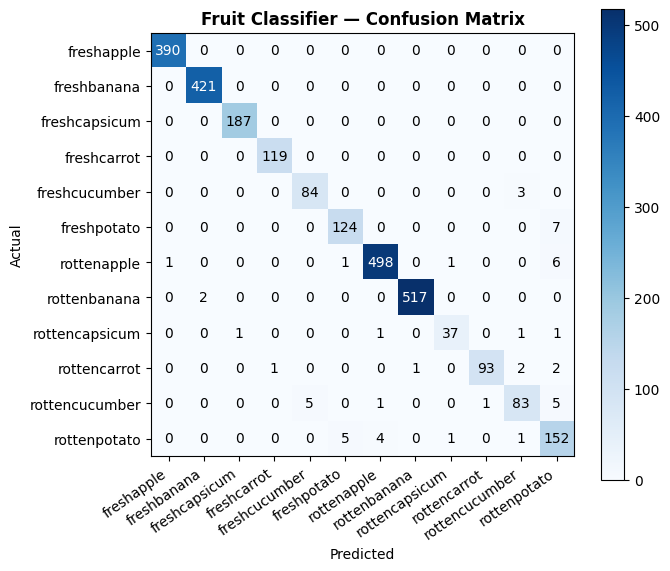

Saved → plot_confusion_fruit.png


In [12]:
cm  = confusion_matrix(ft_test, pred_fruit, labels=FRUITS)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(FRUITS))); ax.set_xticklabels(FRUITS, rotation=35, ha="right")
ax.set_yticks(range(len(FRUITS))); ax.set_yticklabels(FRUITS)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Fruit Classifier — Confusion Matrix", fontweight="bold")
for i in range(len(FRUITS)):
    for j in range(len(FRUITS)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() * 0.5 else "black")
plt.tight_layout()
plt.savefig(f"{a}/plot_confusion_fruit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot_confusion_fruit.png")
